# Using `blsutils` package

This notebook demonstrates how to use my custom `blsutils` package (not on pypi) to obtain number of jobs added on a 1-month or month-to-month basis.  You need to have your own BLS developer API key and also have the series ID you want to plot.  It is assumed you have a `.env` file with "BLS_API_KEY=" assigned.  The series ID for all jobs added, seasonally adjusted is "CES0000000001".

In [1]:
from blsutils import BLSClient
import matplotlib.pyplot as plt
import polars as pl

### Let's look at jobs added trend from 2006 thru 2026 so that we can include 2008-2009 Recession Period, Pre-COVID, COVID, and recent data

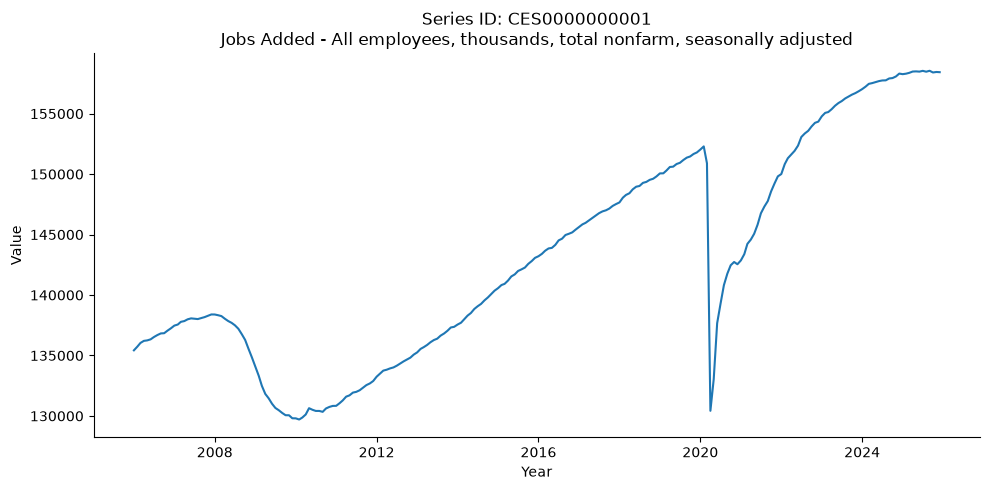

shape: (5, 5)
┌───────────────┬────────────┬──────┬────────┬──────────┐
│ series_id     ┆ year_month ┆ year ┆ period ┆ value    │
│ ---           ┆ ---        ┆ ---  ┆ ---    ┆ ---      │
│ str           ┆ date       ┆ str  ┆ str    ┆ f64      │
╞═══════════════╪════════════╪══════╪════════╪══════════╡
│ CES0000000001 ┆ 2025-08-01 ┆ 2025 ┆ M08    ┆ 158472.0 │
│ CES0000000001 ┆ 2025-09-01 ┆ 2025 ┆ M09    ┆ 158548.0 │
│ CES0000000001 ┆ 2025-10-01 ┆ 2025 ┆ M10    ┆ 158408.0 │
│ CES0000000001 ┆ 2025-11-01 ┆ 2025 ┆ M11    ┆ 158449.0 │
│ CES0000000001 ┆ 2025-12-01 ┆ 2025 ┆ M12    ┆ 158432.0 │
└───────────────┴────────────┴──────┴────────┴──────────┘


In [2]:
with BLSClient() as client:
    df = client.fetch_df("CES0000000001", 2006, 2026)
    client.plot_bls_series(df, "Jobs Added - All employees, thousands, total nonfarm, seasonally adjusted")
    print(df.tail())

Just by looking that trend or slope, things are not look good for 2026 and beyond.  Let's compare the 2 years prior to COVID to the 2 most recent years.

#### Obtain and plot pre-COVID (~ 2018 thru 2019) Jobs Added Totals (in thousands)

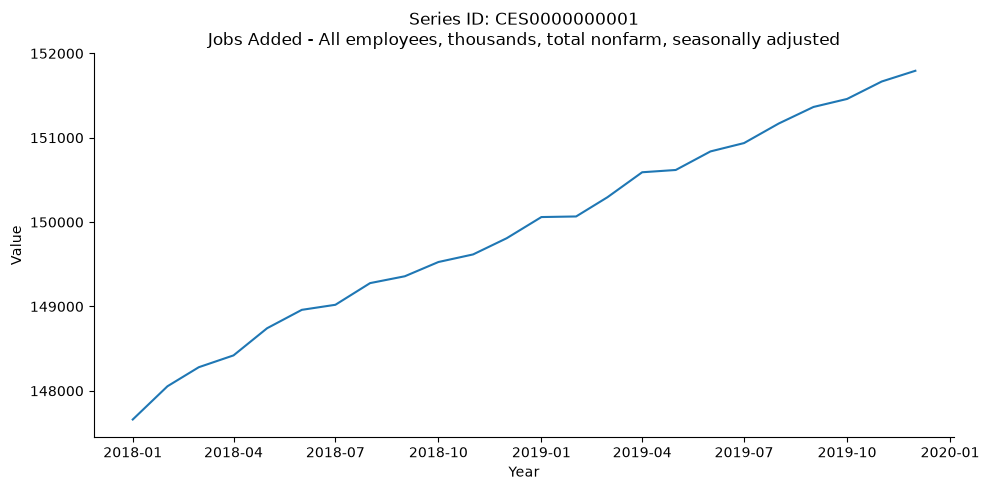

shape: (5, 5)
┌───────────────┬────────────┬──────┬────────┬──────────┐
│ series_id     ┆ year_month ┆ year ┆ period ┆ value    │
│ ---           ┆ ---        ┆ ---  ┆ ---    ┆ ---      │
│ str           ┆ date       ┆ str  ┆ str    ┆ f64      │
╞═══════════════╪════════════╪══════╪════════╪══════════╡
│ CES0000000001 ┆ 2019-08-01 ┆ 2019 ┆ M08    ┆ 151169.0 │
│ CES0000000001 ┆ 2019-09-01 ┆ 2019 ┆ M09    ┆ 151365.0 │
│ CES0000000001 ┆ 2019-10-01 ┆ 2019 ┆ M10    ┆ 151460.0 │
│ CES0000000001 ┆ 2019-11-01 ┆ 2019 ┆ M11    ┆ 151667.0 │
│ CES0000000001 ┆ 2019-12-01 ┆ 2019 ┆ M12    ┆ 151794.0 │
└───────────────┴────────────┴──────┴────────┴──────────┘


In [3]:
with BLSClient() as client:
    df = client.fetch_df("CES0000000001", 2018, 2019)
    client.plot_bls_series(df, "Jobs Added - All employees, thousands, total nonfarm, seasonally adjusted")
    print(df.tail())

#### There isn't a series ID available for 1-month or month-to-month total jobs added.  But we can use polars `diff()` method to calcuate 1-month difference with respect to previous period or in our case, previous month

In [4]:
df = (
    df
    .sort(
        "year",
        "period"
    )
    .with_columns(
        jobs_added_thousands=pl.col("value").diff(),
    )
)

First data point will be `null` since there isn't a previous value

In [5]:
df.head()

series_id,year_month,year,period,value,jobs_added_thousands
str,date,str,str,f64,f64
"""CES0000000001""",2018-01-01,"""2018""","""M01""",147660.0,null
"""CES0000000001""",2018-02-01,"""2018""","""M02""",148054.0,394.0
"""CES0000000001""",2018-03-01,"""2018""","""M03""",148280.0,226.0
"""CES0000000001""",2018-04-01,"""2018""","""M04""",148420.0,140.0
"""CES0000000001""",2018-05-01,"""2018""","""M05""",148742.0,322.0


In [6]:
df.tail()

series_id,year_month,year,period,value,jobs_added_thousands
str,date,str,str,f64,f64
"""CES0000000001""",2019-08-01,"""2019""","""M08""",151169.0,232.0
"""CES0000000001""",2019-09-01,"""2019""","""M09""",151365.0,196.0
"""CES0000000001""",2019-10-01,"""2019""","""M10""",151460.0,95.0
"""CES0000000001""",2019-11-01,"""2019""","""M11""",151667.0,207.0
"""CES0000000001""",2019-12-01,"""2019""","""M12""",151794.0,127.0


### Let's plot the month-to-month jobs added (in thousands)

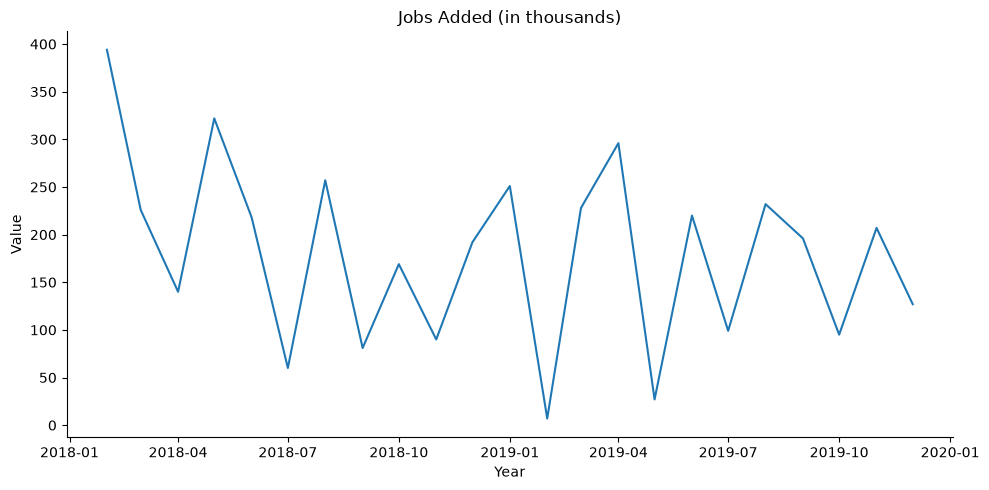

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df["year_month"].to_numpy(),
    df["jobs_added_thousands"].to_numpy(),  # nulls become NaN, which matplotlib draws as a gap
)

ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.set_title("Jobs Added (in thousands)")
ax.spines[["right", "top"]].set_visible(False)

plt.tight_layout()
plt.show()

From above, we can guess the average to be somewhere between 100 and 200.  But let's calculate the exact average.

#### Calcuate Average Month-to-Month Jobs Added (in thousands)

In [8]:
(
    df
    .drop_nulls(subset="jobs_added_thousands")
    ["jobs_added_thousands"]
    .mean()
)

179.7391304347826

### Now, let's compare with recent months

#### Fetch Jobs Added Data for 2025 thru 2026 (for 2026, we only have data thru September, but that's ok)

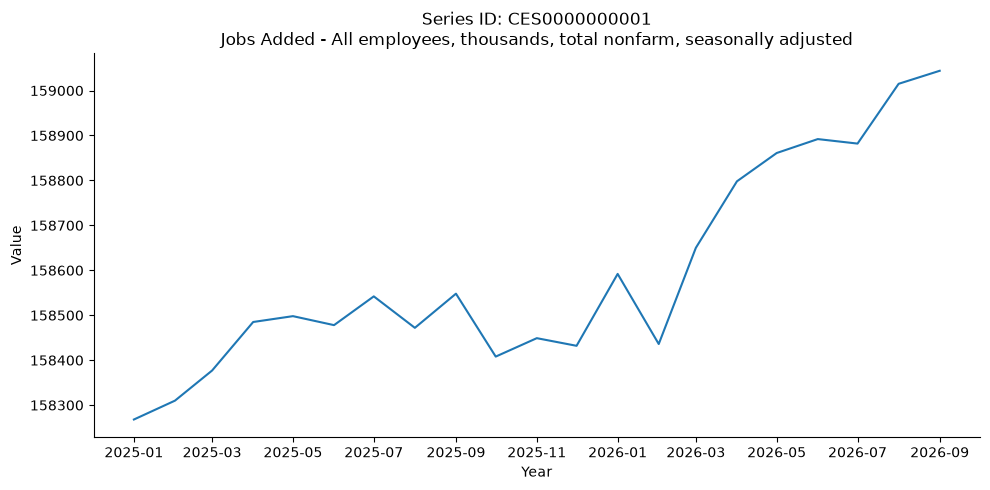

shape: (5, 5)
┌───────────────┬────────────┬──────┬────────┬──────────┐
│ series_id     ┆ year_month ┆ year ┆ period ┆ value    │
│ ---           ┆ ---        ┆ ---  ┆ ---    ┆ ---      │
│ str           ┆ date       ┆ str  ┆ str    ┆ f64      │
╞═══════════════╪════════════╪══════╪════════╪══════════╡
│ CES0000000001 ┆ 2026-05-01 ┆ 2026 ┆ M05    ┆ 158861.0 │
│ CES0000000001 ┆ 2026-06-01 ┆ 2026 ┆ M06    ┆ 158892.0 │
│ CES0000000001 ┆ 2026-07-01 ┆ 2026 ┆ M07    ┆ 158882.0 │
│ CES0000000001 ┆ 2026-08-01 ┆ 2026 ┆ M08    ┆ 159015.0 │
│ CES0000000001 ┆ 2026-09-01 ┆ 2026 ┆ M09    ┆ 159044.0 │
└───────────────┴────────────┴──────┴────────┴──────────┘


In [9]:
with BLSClient() as client:
    df2 = client.fetch_df("CES0000000001", 2025, 2026)
    client.plot_bls_series(df2, "Jobs Added - All employees, thousands, total nonfarm, seasonally adjusted")
    print(df2.tail())

In [10]:
df2 = (
    df2
    .sort(
        "year",
        "period"
    )
    .with_columns(
        jobs_added_thousands=pl.col("value").diff(),
    )
)

In [11]:
df2.tail()

series_id,year_month,year,period,value,jobs_added_thousands
str,date,str,str,f64,f64
"""CES0000000001""",2026-05-01,"""2026""","""M05""",158861.0,63.0
"""CES0000000001""",2026-06-01,"""2026""","""M06""",158892.0,31.0
"""CES0000000001""",2026-07-01,"""2026""","""M07""",158882.0,-10.0
"""CES0000000001""",2026-08-01,"""2026""","""M08""",159015.0,133.0
"""CES0000000001""",2026-09-01,"""2026""","""M09""",159044.0,29.0


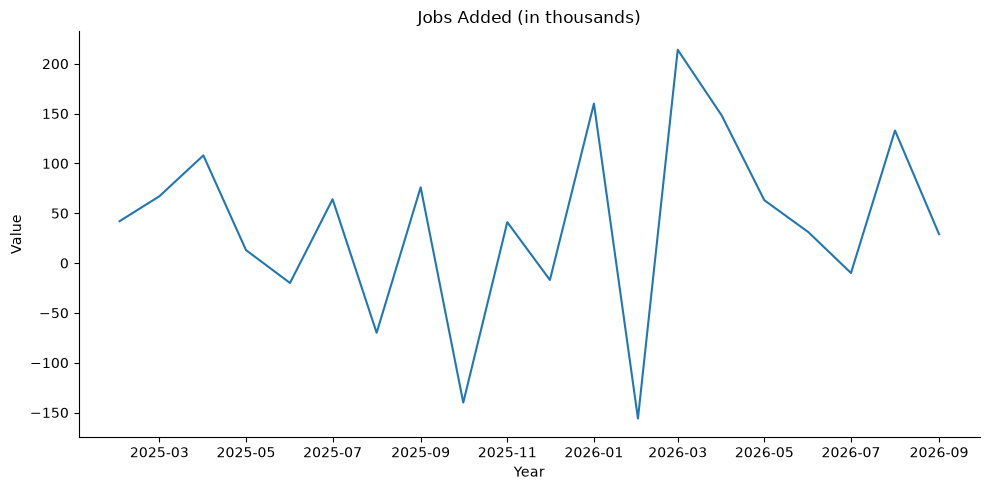

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df2["year_month"].to_numpy(),
    df2["jobs_added_thousands"].to_numpy(),  # nulls become NaN, which matplotlib draws as a gap
)

ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.set_title("Jobs Added (in thousands)")
ax.spines[["right", "top"]].set_visible(False)

plt.tight_layout()
plt.show()

From above, we can estimate that the average lies somewhere between 0 and 50.  But, let's calculate the average exactly.

In [13]:
(
    df2
    .drop_nulls(subset="jobs_added_thousands")
    ["jobs_added_thousands"]
    .mean()
)

38.8

### Ratio of Pre-COVID Avg Monthly Jobs Added to Recent Period Avg Monthly Jobs Added

In [14]:
(
    df
    .drop_nulls(subset="jobs_added_thousands")
    ["jobs_added_thousands"]
    .mean()
) / (
    df2
    .drop_nulls(subset="jobs_added_thousands")
    ["jobs_added_thousands"]
    .mean()
)

4.632451815329449

During 2 years prior to COVID, there were 4.6x more jobs added compared to last 2 recent years